In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.io.shapereader import Reader as ShapeReader

In [2]:
output_file = "/home/lacrio/Documents/thermo_eq_test/data/posproc/thermo_terms_20200201_20200214.nc"
ds_term     = xr.open_dataset(output_file)

output_file = "/home/lacrio/Documents/thermo_eq_test/data/era5_t_uvw_20200201_20200214.nc"
ds_t975     = xr.open_dataset(output_file).sel(pressure_level=975)['t'] - 273.15

In [3]:
# --- Time series at a specific point ---
# Choose the location (latitude, longitude)
lat_point = -63.5
lon_point = -57.0

In [4]:
ds_sel = ds_term.sel(latitude=lat_point, longitude=lon_point, method='nearest')
T975   = ds_t975.sel(latitude=lat_point, longitude=lon_point, method='nearest')

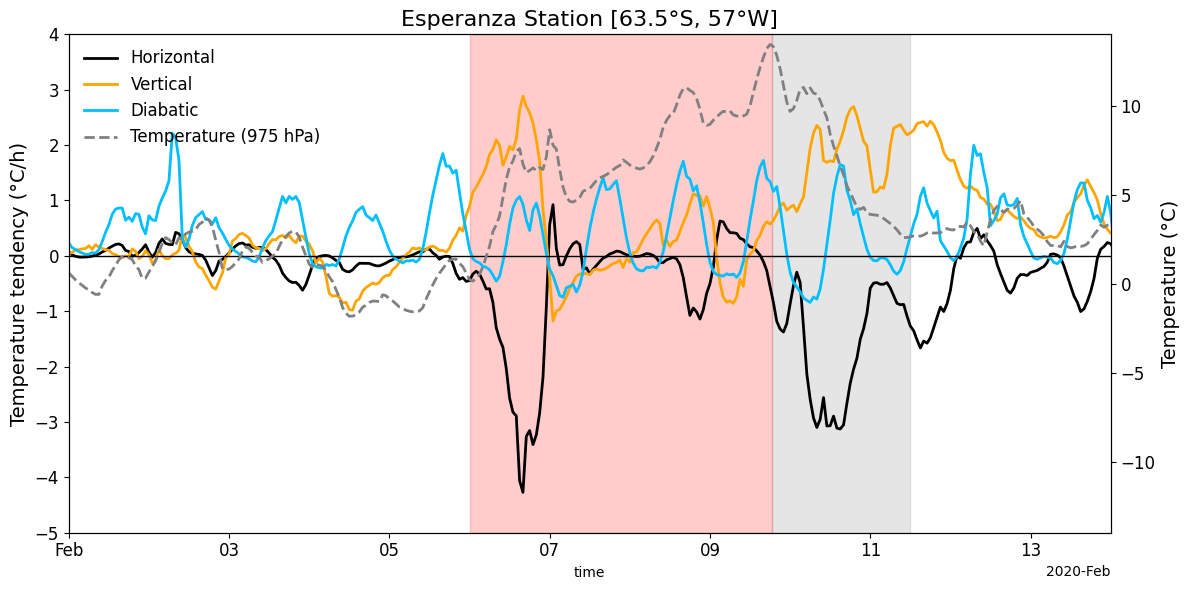

In [5]:
# Create figure and main axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot temperature tendency terms (left axis)
ds_sel.advection_term_975hPa.plot(ax=ax1, label='Horizontal', color='black', linewidth=2)
ds_sel.adiabatic_term_975hPa.plot(ax=ax1, label='Vertical', color='orange', linewidth=2)
ds_sel.diabatic_term_975hPa.plot(ax=ax1, label='Diabatic', color='deepskyblue', linewidth=2)

ax1.set_ylabel('Temperature tendency (°C/h)', fontsize=14)
ax1.set_ylim(-5, 4)
ax1.axhline(0, color='black', linestyle='-', linewidth=1)
ax1.set_xlim(pd.to_datetime('20200201'), pd.to_datetime('20200214'))
ax1.set_title('Esperanza Station [63.5°S, 57°W]', fontsize=16)

# Increase tick label font size
ax1.tick_params(axis='both', labelsize=12)

# Add shading for specific periods
ax1.axvspan(pd.to_datetime("2020-02-06"), pd.to_datetime("2020-02-09T18:30"), color='red', alpha=0.2)
ax1.axvspan(pd.to_datetime("2020-02-09T18:30"), pd.to_datetime("2020-02-11T12"), color='grey', alpha=0.2)

# Second Y axis (right): absolute temperature
ax2 = ax1.twinx()
T975.plot(ax=ax2, color='grey', label='Temperature (975 hPa)', linewidth=2, linestyle='--')
ax2.set_ylabel('Temperature (°C)', fontsize=14)
ax2.set_ylim(-14, 14)
ax2.tick_params(axis='both', labelsize=12)
ax2.set_title('')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=12, frameon=False)

plt.tight_layout()
fig.savefig('./fig/temp_tendency_temporal.png', dpi=300, facecolor='w', bbox_inches='tight', pad_inches=0.1)
plt.show()


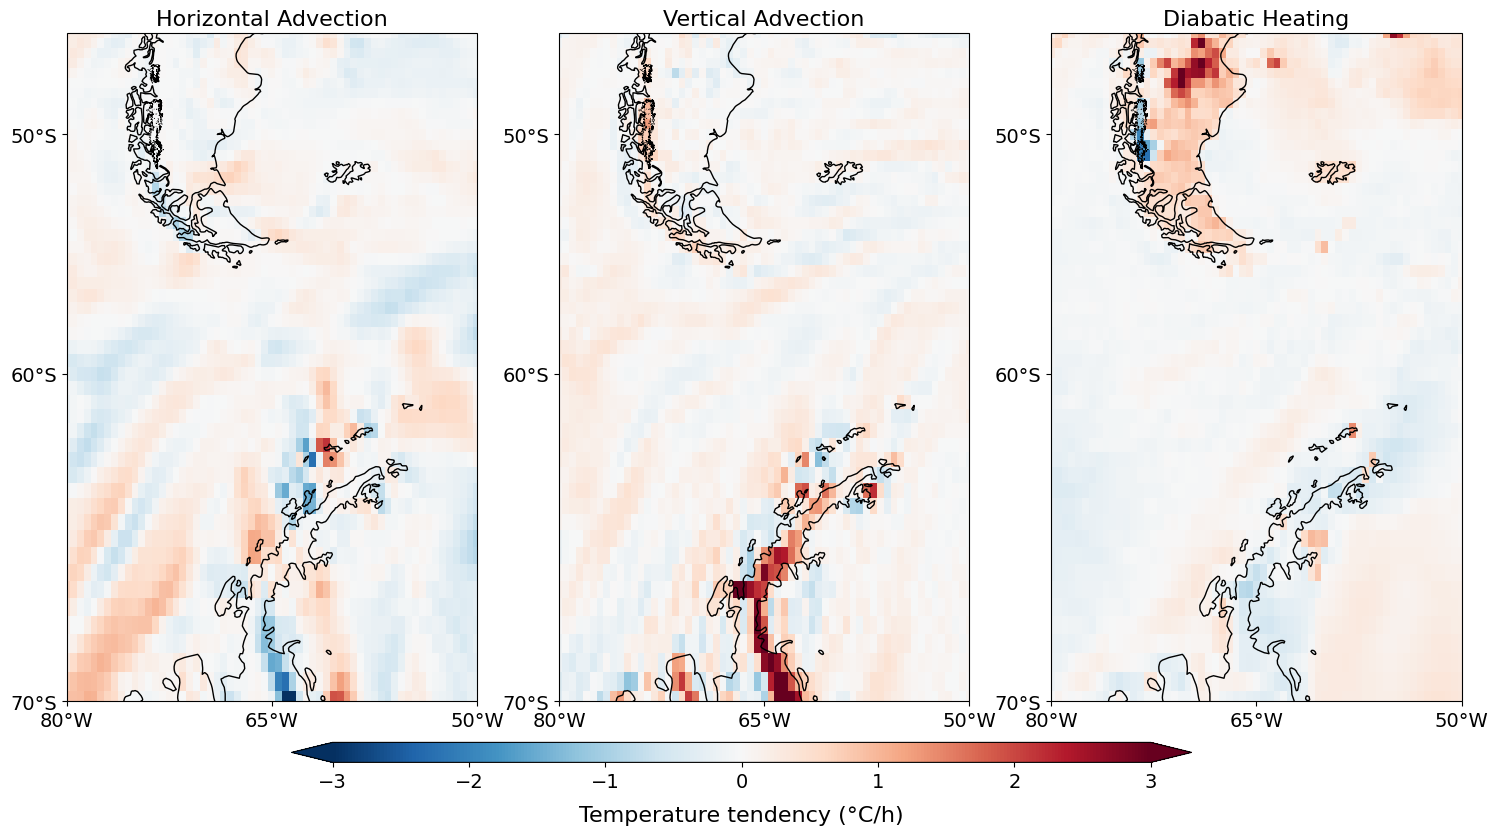

In [6]:
# --- Select time ---
ds_term_sel_12UTC = ds_term.sel(valid_time='20200207T12')

# --- Define projections ---
proj_map = ccrs.Mercator()
proj_data = ccrs.PlateCarree()

# --- Figure setup ---
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig,
                       width_ratios=[1, 1, 1],
                       height_ratios=[1,])

# --- Geographic ticks and extent ---
xticks = np.arange(-110, -30, 15)
yticks = np.arange(-70, -25, 10)
extent = [-80, -50, -70, -45]

# --- Define contour levels and colormaps ---
levels_t2m = np.arange(-3, 3.5, 0.5)
cmap_t2m = plt.get_cmap("RdBu_r")

vars = ['advection_term_975hPa', 'adiabatic_term_975hPa', 'diabatic_term_975hPa'] 

shp_path = '/home/lacrio/Patagonia-Antarctic_Peninsula/data/shp/Glaciers_NPI_SPI.shp'

# Simplify geometries (reduce vertex density)
geoms = []
for geom in ShapeReader(shp_path).geometries():
    geoms.append(geom.simplify(0.05))  # adjust tolerance (degrees); 0.05–0.1 works well

# =========================================================
# --- PLOTS ---
# =========================================================
for i in range(3):
    ax = fig.add_subplot(gs[0, i], projection=proj_map)

    # Add base map features
    ax.coastlines(resolution='50m')
    #ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Contourf plot
#    t2m_plot = ax.contourf(
#        ds_term_sel_12UTC.longitude, ds_term_sel_12UTC.latitude, ds_term_sel_12UTC[vars[i]],
#        levels=levels_t2m, cmap=cmap_t2m, extend='both',
#        transform=proj_data
#    )

    t2m_plot = ax.pcolormesh(
        ds_term_sel_12UTC.longitude, ds_term_sel_12UTC.latitude, ds_term_sel_12UTC[vars[i]],
        vmin=-3, vmax=3, shading='auto', cmap=cmap_t2m,
        transform=proj_data
    )

    ax.add_geometries(geoms, facecolor='none', edgecolor='k', lw=0.4, crs=proj_data)

    # Ticks and labels (larger font size)
    ax.set_xticks(xticks, crs=proj_data)
    ax.set_yticks(yticks, crs=proj_data)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.set_extent(extent, crs=proj_data)
    ax.tick_params(axis='both', labelsize=14)  # Increase tick font size

    # Title for each panel (optional)
    titles = ["Horizontal Advection", "Vertical Advection", "Diabatic Heating"]
    ax.set_title(titles[i], fontsize=16)

# --- Colorbar ---
cbar1_ax = fig.add_axes([0.25, 0.10, 0.5, 0.02])  # [left, bottom, width, height]

#cbar1 = fig.colorbar(t2m_plot, cax=cbar1_ax, orientation='horizontal')

cbar1 = fig.colorbar(t2m_plot, cax=cbar1_ax, orientation='horizontal', extend='both')

cbar1.set_label("Temperature tendency (°C/h)", fontsize=16, labelpad=10)
cbar1.ax.tick_params(labelsize=14)  # Increase colorbar tick font size

fig.savefig('fig/temp_tendency_spatial.png', dpi=300, facecolor='w', bbox_inches='tight', pad_inches=0.1)

#plt.subplots_adjust(wspace=0.1, bottom=0.1, top=0.92)
#plt.show()
